# Préparation express — Soutenance YOLO26n-OBB

Ce notebook est volontairement séparé du notebook principal. Il sert à **comprendre, répéter et démontrer** sans modifier le livrable complet ni dépendre de l'état d'exécution de ses cellules.

## Objectif pour demain

À la fin de cette préparation, tu dois pouvoir :

1. justifier le choix de **YOLO26n-OBB-1024** en une minute ;
2. expliquer son fonctionnement en cinq étapes ;
3. expliquer la formule de l'IoU orientée avec une intuition simple ;
4. commenter le code et les résultats préliminaires ;
5. lancer la démonstration finale avec une seule cellule.

> Règle de travail : réponds d'abord à voix haute, puis ouvre les réponses. Le but n'est pas de mémoriser chaque phrase, mais de reconstruire le raisonnement.

## Programme conseillé — environ 5 heures

| Temps | Travail | Critère de réussite |
|---:|---|---|
| 15 min | Lire le fil conducteur et situer la cellule 41 | Expliquer où tu en es sans dire seulement un numéro de cellule |
| 45 min | CNN : convolution, backbone, neck, head | Expliquer le trajet d'une image en 45 secondes |
| 60 min | YOLO-OBB et ses cinq étapes | Refaire les cinq étapes sans regarder |
| 50 min | IoU, confiance, NMS et mAP | Distinguer clairement les quatre notions |
| 40 min | Code et résultats | Commenter les cellules importantes et trois chiffres |
| 30 min | Démonstration autonome | Lancer la cellule après redémarrage du noyau |
| 60 min | Trois répétitions chronométrées | Finir entre 9 min 15 s et 9 min 45 s |

Si tu disposes d'une sixième heure, utilise-la uniquement pour les questions/réponses à la fin de ce notebook.

**À ne pas faire ce soir :** reprendre linéairement toutes les cellules 41 à 83, réentraîner un modèle ou étudier toute l'architecture mathématique de YOLO.

## 1. Le fil conducteur de toute la présentation

### Question à voix haute

En une phrase, quel problème as-tu résolu et quelle est ta conclusion principale ?

<details>
<summary><strong>Réponse de référence — environ 20 secondes</strong></summary>

Mon objectif est de détecter des objets de quinze classes dans des images aériennes DOTA. Comme ces objets peuvent être petits et inclinés, j'ai choisi YOLO26n avec des boîtes orientées et une résolution de 1024 pixels. Sur ma validation, ce modèle est plus précis et plus rapide que ma baseline Faster R-CNN à boîtes horizontales.

</details>

Le raisonnement complet tient dans cette chaîne :

**objets aériens orientés → boîtes OBB → YOLO en une étape → IoU orientée → validation → comparaison avec la baseline**

## 2. Où tu en es réellement : la cellule 41

La cellule 41 de `projet_dota_soutenance.ipynb` ne commence pas encore YOLO. Elle prépare la **baseline Faster R-CNN** :

1. elle construit les jeux de données train et validation à boîtes horizontales ;
2. elle conserve les tuiles qui contiennent au moins un objet ;
3. elle crée le `DataLoader` et vérifie un exemple.

### Ce qu'il faut savoir dire

> Faster R-CNN est ma baseline de comparaison. Je l'ai alimenté avec des boîtes horizontales. Mon modèle principal arrive plus tard, aux cellules 51–52 : YOLO26n-OBB-1024.

Tu n'as pas besoin de maîtriser tous les détails de Faster R-CNN pour demain. Il faut surtout comprendre son rôle : fournir un **point de référence expérimental**.

## 3. CNN : le minimum indispensable

Un CNN apprend des filtres qui parcourent l'image. Au début, les filtres réagissent à des motifs simples, comme des bords ou des textures. En empilant les couches, le réseau construit des caractéristiques plus abstraites, utiles pour reconnaître et localiser les objets.

| Élément | Rôle simple | Dans notre cas |
|---|---|---|
| Convolution | Applique de petits filtres appris | Repère contours, textures et formes |
| Carte de caractéristiques | Résultat spatial d'un filtre | Indique où un motif est présent |
| Backbone | Extrait les caractéristiques | Transforme les pixels en représentations utiles |
| Neck | Fusionne plusieurs échelles | Aide pour les petits et grands objets |
| Head OBB | Produit les prédictions finales | Classe, confiance et boîte orientée |

### Réponse orale courte

> Le backbone transforme l'image en cartes de caractéristiques. Le neck combine plusieurs résolutions pour conserver les détails des petits objets. La tête OBB utilise ensuite ces informations pour prédire la classe, la confiance et la géométrie orientée de chaque objet.

### Test actif — CNN

Réponds avant d'ouvrir chaque bloc.

<details><summary><strong>Pourquoi plusieurs couches de convolution ?</strong></summary>Les premières détectent des motifs simples ; les couches suivantes les combinent en motifs plus complexes et utiles pour reconnaître les objets.</details>

<details><summary><strong>Pourquoi plusieurs échelles ?</strong></summary>Dans DOTA, les objets ont des tailles très différentes. Une représentation fine aide pour les petits objets, tandis qu'une représentation plus globale apporte du contexte.</details>

<details><summary><strong>Le réseau contient-il des filtres choisis à la main ?</strong></summary>Non. Les valeurs des filtres sont apprises pendant l'entraînement à partir de l'erreur entre prédictions et annotations.</details>

<details><summary><strong>Différence entre backbone et head ?</strong></summary>Le backbone extrait les caractéristiques ; la head les transforme en prédictions de classes et de boîtes.</details>

## 4. Pourquoi YOLO26n-OBB-1024 ?

### Quatre raisons à connaître

1. **OBB correspond à la géométrie de DOTA.** Un avion, un navire ou un pont peut être incliné ; une boîte orientée épouse mieux l'objet.
2. **YOLO est un détecteur en une étape.** Il produit directement les prédictions à partir des caractéristiques, ce qui favorise la vitesse.
3. **Le modèle `n` reste compact.** Il est réaliste pour une RTX 4060 et un projet étudiant.
4. **La résolution 1024 conserve plus de détails.** Elle est utile pour les petits objets aériens et a donné la meilleure variante YOLO testée.

### Formulation d'une minute

> J'ai choisi YOLO26n-OBB parce que le dataset DOTA contient beaucoup d'objets orientés et parfois très petits. Les boîtes horizontales englobent souvent trop d'arrière-plan, tandis que les boîtes orientées suivent mieux la forme de l'objet. YOLO effectue la détection en une étape et reste rapide. La variante nano est compatible avec mon matériel, et la résolution 1024 a mieux préservé les petits détails que 640. Enfin, ce choix est confirmé empiriquement par de meilleurs résultats que ma baseline Faster R-CNN.

## 5. YOLO-OBB en cinq étapes

1. **Entrée** — une tuile aérienne est redimensionnée pour une inférence en 1024 × 1024.
2. **Backbone CNN** — le réseau extrait des caractéristiques visuelles à partir des pixels.
3. **Fusion multi-échelle** — le neck combine des caractéristiques fines et plus globales.
4. **Prédictions OBB** — la tête prédit la classe, la confiance et une boîte orientée pour chaque candidat.
5. **Post-traitement** — le seuil de confiance retire les candidats faibles et la NMS orientée supprime les doublons fortement superposés.

### Transition vers la formule

> Pour décider si deux boîtes se superposent fortement et pour évaluer la localisation, on a besoin d'une mesure géométrique : l'Intersection over Union, ou IoU.

### Attention au vocabulaire

- **Entraînement** : ajuster les poids avec les annotations.
- **Validation** : mesurer les performances sur des images non utilisées pour ajuster les poids.
- **Inférence** : utiliser les poids déjà appris pour produire des prédictions.

## 6. Les cellules du notebook principal à connaître

| Cellule | Ce qu'elle montre | Phrase à dire |
|---:|---|---|
| 41 | Préparation de la baseline Faster R-CNN | « Je construis ici le chargeur de données HBB de la baseline. » |
| 43–44 | Construction et test de Faster R-CNN | « Le smoke test vérifie que données, boîtes et modèle sont compatibles. » |
| 51–52 | Modèle principal YOLO-OBB | « Si le meilleur poids existe, je le charge ; je ne réentraîne pas. » |
| 53–56 | Validation et métriques | « J'évalue sur le split validation avec des métriques de détection. » |
| 57–60 | Comparaison et prédictions | « Je compare les modèles puis j'inspecte visuellement les résultats. » |

Pour la démonstration, ne déroule pas toutes ces cellules. Utilise la cellule autonome à la fin de ce notebook.

In [ ]:
from pathlib import Path
import pandas as pd

def trouver_racine_projet(depart):
    for dossier in [depart, *depart.parents]:
        if (dossier / "projet_dota_soutenance.ipynb").exists():
            return dossier
    raise FileNotFoundError("Racine du projet introuvable.")

PROJECT_DIR = trouver_racine_projet(Path.cwd().resolve())
yolo = pd.read_csv(PROJECT_DIR / "outputs/analysis/yolo_obb_metrics.csv").iloc[0]

resultats = pd.DataFrame([
    {"Modèle": "Faster R-CNN HBB", "F1": 0.213, "mAP50": 0.142,
     "mAP50-95": 0.060, "Inférence (ms/image)": 17.1},
    {"Modèle": "YOLO26n-OBB-1024", "F1": float(yolo["F1"]),
     "mAP50": float(yolo["mAP50"]), "mAP50-95": float(yolo["mAP50-95"]),
     "Inférence (ms/image)": float(yolo["Inference ms/image"])},
])
resultats.round(3)

### Comment interpréter les résultats

Trois chiffres suffisent pour la présentation :

- **F1 : 0,386 contre 0,213** — meilleur compromis entre précision et rappel ;
- **mAP50-95 : 0,185 contre 0,060** — meilleure qualité globale de détection et de localisation ;
- **7,9 ms contre 17,1 ms par image** — inférence interne plus rapide dans la validation enregistrée.

### Interprétation honnête

> YOLO-OBB est clairement meilleur que la baseline dans cette expérience, mais les scores restent modestes. Le rappel proche de 0,29 indique qu'une partie importante des objets n'est pas détectée. Ce sont donc des résultats préliminaires, pas un système prêt pour la production.

Le temps affiché par la validation mesure surtout l'inférence du modèle. La première cellule lancée en direct prend aussi le temps de charger les poids et d'initialiser le GPU.

## 7. Formule importante : l'IoU orientée

Pour deux boîtes $A$ et $B$ :

$$
IoU(A,B)=\frac{|A \cap B|}{|A \cup B|}
=\frac{|A \cap B|}{|A|+|B|-|A \cap B|}
$$

- Le numérateur est l'aire commune.
- Le dénominateur est l'aire totale couverte par au moins une des deux boîtes.
- $IoU=0$ signifie aucune superposition.
- $IoU=1$ signifie une superposition parfaite.

Pour des boîtes orientées, la formule ne change pas. La difficulté vient du calcul de l'intersection entre deux polygones inclinés.

### Exemple oral

Si chaque boîte a une aire de 100 et que leur intersection vaut 60, l'union vaut $100+100-60=140$. L'IoU vaut donc $60/140 \approx 0{,}43$.

In [ ]:
aire_a = 100
aire_b = 100
intersection = 60
union = aire_a + aire_b - intersection
iou = intersection / union

print(f"Union = {aire_a} + {aire_b} - {intersection} = {union}")
print(f"IoU = {intersection} / {union} = {iou:.3f}")

## 8. Ne pas confondre IoU, confiance, NMS et mAP

| Notion | Question à laquelle elle répond |
|---|---|
| Confiance | À quel point le modèle croit-il à cette prédiction ? |
| IoU | À quel point deux boîtes se superposent-elles géométriquement ? |
| NMS orientée | Parmi plusieurs prédictions redondantes, lesquelles conserver ? |
| Précision | Parmi les prédictions conservées, combien sont correctes ? |
| Rappel | Parmi les objets réels, combien ont été retrouvés ? |
| mAP50 | Performance moyenne avec un seuil IoU de 0,50 |
| mAP50-95 | Moyenne sur plusieurs seuils IoU de 0,50 à 0,95, donc plus exigeante |

### Formulation sûre sur la NMS

> Si plusieurs boîtes prédisent probablement le même objet, la NMS garde d'abord la plus confiante, puis supprime les autres lorsque leur IoU avec elle dépasse le seuil choisi. Avec des OBB, la superposition doit tenir compte de l'orientation.

### Nuance importante

L'IoU est centrale pour l'évaluation et la gestion des superpositions. Il ne faut pas affirmer que la formule d'IoU standard est, à elle seule, toute la fonction de perte utilisée pour entraîner YOLO26-OBB.

## 9. Questions probables du professeur

<details><summary><strong>Pourquoi ne pas utiliser uniquement des boîtes horizontales ?</strong></summary>Elles contiennent souvent davantage d'arrière-plan pour un objet incliné et décrivent moins précisément sa géométrie. Les OBB ajoutent l'orientation.</details>

<details><summary><strong>Pourquoi le rappel est-il plus faible que la précision ?</strong></summary>Le modèle reste relativement sélectif : une partie de ses prédictions est correcte, mais il manque encore beaucoup d'objets, notamment petits, denses ou difficiles.</details>

<details><summary><strong>Pourquoi mAP50-95 est-il inférieur à mAP50 ?</strong></summary>mAP50-95 exige une bonne correspondance à des seuils IoU de plus en plus stricts. Une boîte approximative peut réussir à 0,50 mais échouer à 0,75 ou 0,95.</details>

<details><summary><strong>Pourquoi 1024 plutôt que 640 ?</strong></summary>La résolution 1024 conserve davantage de pixels sur les petits objets. Elle coûte plus de calcul, mais elle a produit la meilleure variante YOLO testée.</details>

<details><summary><strong>Le résultat prouve-t-il que YOLO est toujours supérieur à Faster R-CNN ?</strong></summary>Non. Il montre seulement que, dans cette expérience, avec ces représentations, ces réglages et ce sous-ensemble, YOLO-OBB a obtenu de meilleurs résultats.</details>

<details><summary><strong>Quelle est la principale limite ?</strong></summary>Le rappel reste proche de 0,29 et l'expérience utilise un sous-ensemble de DOTA. Il faudrait davantage de données, de réglages et d'analyse par classe pour généraliser davantage.</details>

## 10. Démonstration autonome

La cellule suivante ne dépend d'aucune cellule précédente. Elle :

- localise automatiquement la racine du projet ;
- charge le meilleur poids YOLO26n-OBB-1024 ;
- utilise une tuile de validation fixe ;
- choisit le GPU si disponible, sinon le CPU ;
- affiche les classes, les scores, le nombre de détections et les OBB.

La première exécution comprend le chargement du modèle et l'initialisation du GPU. Elle est donc plus longue que la seule mesure d'inférence enregistrée pendant la validation.

Modèle : YOLO26n-OBB-1024
Image : P0249__x0_y653.jpg
Périphérique : 0
Détections conservées : 16
Temps total de la cellule : 0.98 s
Inférence interne : 54.7 ms


,classe,confiance
0,plane,0.966
1,plane,0.956
2,plane,0.948
3,plane,0.921
4,plane,0.900
5,plane,0.859
6,plane,0.789
7,plane,0.768
8,plane,0.741
9,plane,0.633


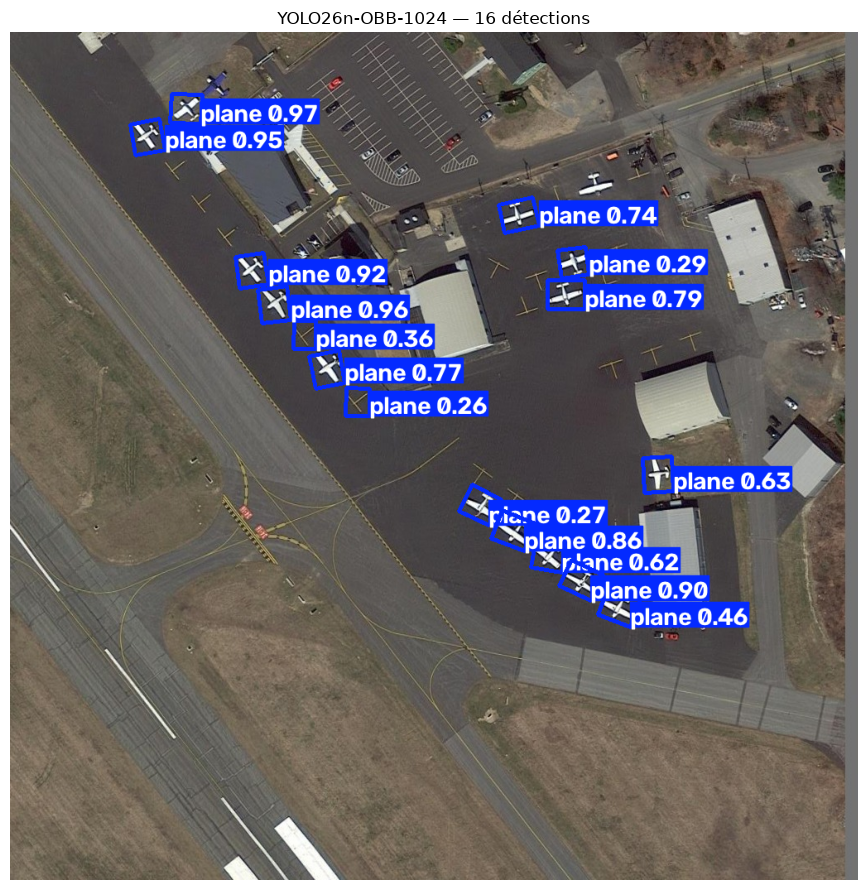

In [1]:
# Cette cellule est autonome : elle peut être exécutée après un redémarrage du noyau.
from pathlib import Path
from time import perf_counter
import os

def trouver_racine_demo(depart):
    poids_relatif = Path("runs/dota_experiment_v1/tuned_obb_yolo26n_e20_img1024/weights/best.pt")
    for dossier in [depart, *depart.parents]:
        if (dossier / poids_relatif).exists():
            return dossier
    raise FileNotFoundError("Impossible de retrouver les poids YOLO depuis le dossier courant.")

PROJECT_DIR = trouver_racine_demo(Path.cwd().resolve())
os.environ.setdefault("YOLO_CONFIG_DIR", str(PROJECT_DIR / ".ultralytics_config"))

import matplotlib.pyplot as plt
import pandas as pd
import torch
from IPython.display import display
from ultralytics import YOLO

WEIGHTS_PATH = PROJECT_DIR / "runs/dota_experiment_v1/tuned_obb_yolo26n_e20_img1024/weights/best.pt"
IMAGE_PATH = PROJECT_DIR / "prepared_data/dota_experiment_v1/obb/images/val/P0249__x0_y653.jpg"
device = 0 if torch.cuda.is_available() else "cpu"

debut = perf_counter()
model = YOLO(str(WEIGHTS_PATH))
resultat = model.predict(
    source=str(IMAGE_PATH), imgsz=1024, conf=0.25, iou=0.7,
    max_det=100, device=device, verbose=False,
)[0]
temps_total = perf_counter() - debut

nombre_detections = 0 if resultat.obb is None else len(resultat.obb)
print(f"Modèle : YOLO26n-OBB-1024")
print(f"Image : {IMAGE_PATH.name}")
print(f"Périphérique : {device}")
print(f"Détections conservées : {nombre_detections}")
print(f"Temps total de la cellule : {temps_total:.2f} s")
print(f"Inférence interne : {resultat.speed.get('inference', float('nan')):.1f} ms")

if resultat.obb is not None and nombre_detections:
    classes = resultat.obb.cls.cpu().numpy().astype(int)
    confiances = resultat.obb.conf.cpu().numpy()
    tableau = pd.DataFrame({
        "classe": [resultat.names[int(classe)] for classe in classes],
        "confiance": confiances,
    }).sort_values("confiance", ascending=False)
    display(tableau.round({"confiance": 3}).head(20))

image_annotee_rgb = resultat.plot()[:, :, ::-1]
plt.figure(figsize=(9, 9))
plt.imshow(image_annotee_rgb)
plt.title(f"YOLO26n-OBB-1024 — {nombre_detections} détections")
plt.axis("off")
plt.tight_layout()
plt.show()

### Image de secours déjà calculée

Si la cellule ne peut pas être relancée pendant la présentation, utilise directement cette sortie :

![Prédictions YOLO26n-OBB sur la tuile P0249](outputs/presentation_assets/demo_p0249_yolo_obb.jpg)

### Ce qu'il faut dire pendant l'exécution

> Je charge le meilleur poids déjà entraîné, puis j'envoie une tuile de validation jamais utilisée pour ajuster les poids. Le seuil de confiance est fixé à 0,25 et la NMS utilise un seuil d'IoU de 0,7. Le résultat contient la classe, la confiance et une boîte orientée pour chaque prédiction conservée.

## 11. Déroulé final des 10 minutes

| Temps | Action | Message principal |
|---:|---|---|
| 0:00–1:00 | Diapositive 1, partie gauche | DOTA contient des objets petits et orientés ; YOLO-OBB-1024 est adapté et réaliste |
| 1:00–4:00 | Diapositive 1, cinq étapes | Entrée → backbone → neck → head OBB → confiance et NMS |
| 4:00–7:00 | Diapositive 2, IoU | Intersection divisée par union ; même formule pour les polygones orientés |
| 7:00–8:00 | Diapositive 2, résultats | F1 0,386 ; mAP50-95 0,185 ; 7,9 ms/image |
| 8:00–9:15 | Notebook de démo | Chargement des poids, inférence et lecture des OBB |
| 9:15–9:40 | Conclusion | Meilleur que la baseline, mais rappel encore limité |
| 9:40–10:00 | Marge | Transition ou interruption du professeur |

### Conclusion à mémoriser

> Le choix des boîtes orientées est cohérent avec la géométrie de DOTA, et les résultats confirment l'intérêt de YOLO26n-OBB-1024 face à ma baseline. Le modèle reste perfectible, surtout sur le rappel, mais le pipeline complet fonctionne et produit des résultats reproductibles.

## Checklist finale

- [ ] Je peux expliquer le projet en une phrase.
- [ ] Je peux définir convolution, backbone, neck et head.
- [ ] Je peux refaire les cinq étapes sans regarder.
- [ ] Je peux calculer l'exemple d'IoU $60/140$.
- [ ] Je ne confonds pas confiance, IoU, NMS et mAP.
- [ ] Je connais F1 = 0,386, mAP50-95 = 0,185 et 7,9 ms/image.
- [ ] Je sais reconnaître que le rappel de 0,291 reste une limite.
- [ ] J'ai exécuté la cellule de démo après un redémarrage du noyau.
- [ ] J'ai le PowerPoint et le dépôt disponibles hors connexion.
- [ ] Ma dernière répétition dure moins de 9 min 45 s.

### Carte mentale finale

**Pourquoi ?** orientation et petits objets → **Comment ?** CNN et tête OBB → **Mesure ?** IoU et mAP → **Preuve ?** meilleurs résultats que Faster R-CNN → **Limite ?** rappel encore faible.